In [4]:
import pandas as pd

df = pd.read_csv(r"C:\Users\arnav\Downloads\Sentiment-Intelligence-Engine\data\raw\Playstore\playstore_reviews_dataset.csv")

df = df.rename(columns={
"app":"app_name",
"review_text":"review_text",
"rating":"rating",
"review_time":"review_time",
"thumbs_up_count":"thumbs_up_count",
"app_version":"app_version",
"developer_reply":"developer_reply"
})

df = df[
[
'review_id',
'app_name',
'review_text',
'rating',
'review_time',
'thumbs_up_count',
'app_version',
'developer_reply'
]
]

df = df.dropna(subset=['review_text'])

df.to_csv(r"C:\Users\arnav\Downloads\Sentiment-Intelligence-Engine\data\processed\app_reviews_dataset.csv",index=False)

print("App dataset shape:",df.shape)

C:\Users\arnav\AppData\Local\Temp\ipykernel_16524\1644375702.py:3: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Users\arnav\Downloads\Sentiment-Intelligence-Engine\data\raw\Playstore\playstore_reviews_dataset.csv")


App dataset shape: (999957, 8)


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

# Consistent plot style across all notebooks
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

In [6]:
print(f"Shape: {df.shape}")
print(f"Apps covered: {df['app_name'].nunique()}")
print(df["app_name"].value_counts())

Shape: (999957, 8)
Apps covered: 8
app_name
Flipkart     125000
Instagram    124998
Snapchat     124998
WhatsApp     124997
Spotify      124997
YouTube      124995
Telegram     124987
Amazon       124985
Name: count, dtype: int64


In [7]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import os

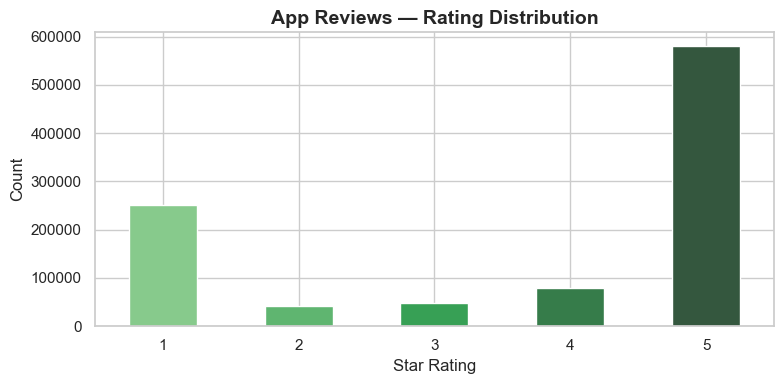

In [11]:
# Cell 2 — Rating Distribution
fig, ax = plt.subplots(figsize=(8, 4))
df["rating"].value_counts().sort_index().plot(
    kind="bar", color=sns.color_palette("Greens_d", 5), edgecolor="white"
)
ax.set_title("App Reviews — Rating Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Star Rating")
ax.set_ylabel("Count")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig(r"C:\Users\arnav\Downloads\Sentiment-Intelligence-Engine\notebooks\eda\app\rating_distribution.png", dpi=150)
plt.show()

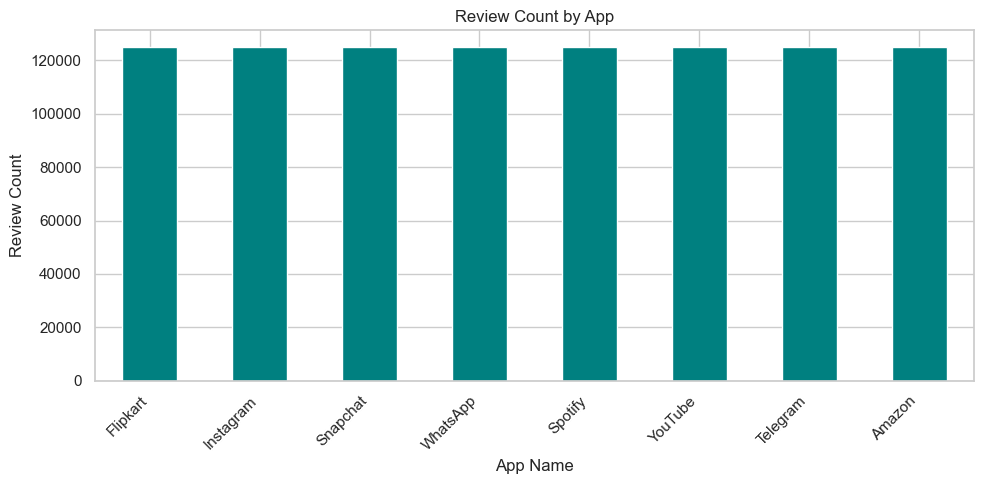

In [12]:
app_counts = df["app_name"].value_counts()

ax = app_counts.plot(kind="bar", color="teal", edgecolor="white")
ax.set_title("Review Count by App")
ax.set_xlabel("App Name")
ax.set_ylabel("Review Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(r"C:\Users\arnav\Downloads\Sentiment-Intelligence-Engine\notebooks\eda\app\top_apps.png", dpi=150)
plt.show()

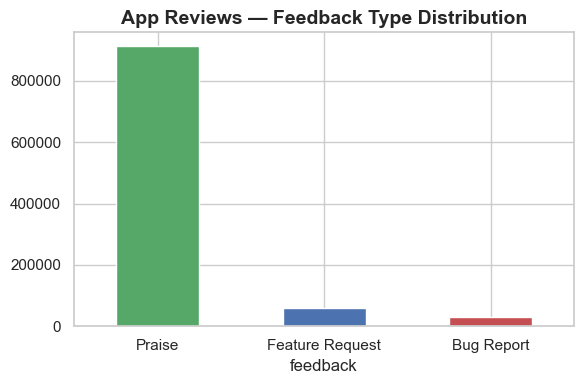

In [13]:
# Cell 4 — Feedback Type Distribution
def classify(text):
    text = str(text).lower()
    if any(w in text for w in ["crash","bug","error","fix","broken"]):
        return "Bug Report"
    elif any(w in text for w in ["feature","add","wish","would","update"]):
        return "Feature Request"
    else:
        return "Praise"

df["feedback"] = df["review_text"].apply(classify)
fig, ax = plt.subplots(figsize=(6, 4))
df["feedback"].value_counts().plot(
    kind="bar", ax=ax,
    color=["#55A868","#4C72B0","#C44E52"], edgecolor="white"
)
ax.set_title("App Reviews — Feedback Type Distribution",
             fontsize=14, fontweight="bold")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig(r"C:\Users\arnav\Downloads\Sentiment-Intelligence-Engine\notebooks\eda\app\feedback_distribution.png", dpi=150)
plt.show()

In [6]:
# Analyze low-rated reviews specifically — most likely to contain bug language
low_rated = df[df["rating"] <= 2]["review_text"]

vec = CountVectorizer(stop_words="english", max_features=40)
vec.fit_transform(low_rated)
keywords = vec.get_feature_names_out()
print("Top 40 keywords in 1–2 star app reviews:")
print(keywords)

# Bug signals to look for:
# crash, bug, error, update, fix, slow, freeze, broken, login, load

Top 40 keywords in 1–2 star app reviews:
['account' 'ads' 'amazon' 'app' 'bad' 'code' 'customer' 'delivery' 'doesn'
 'don' 'fix' 'good' 'just' 'like' 'login' 'make' 'memories' 'money'
 'music' 'new' 'order' 'pay' 'people' 'phone' 'premium' 'problem'
 'service' 'sms' 'snapchat' 'songs' 'telegram' 'time' 'update' 'use' 've'
 'video' 'want' 'working' 'worst' 'youtube']


In [17]:
#to combine all the tweets
sentences = df['review_text'].tolist()
len(sentences)

999957

In [22]:
sentences_to_string = " ".join(df["review_text"].dropna().astype(str).sample(
    min(100000, len(df))))

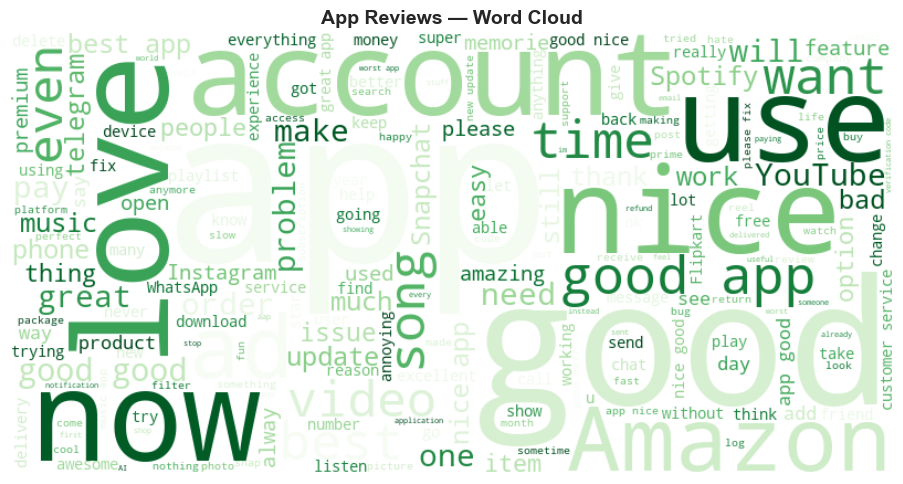


All App EDA images saved to reports/eda/app/


In [23]:
from wordcloud import WordCloud
wc = WordCloud(width=800, height=400, background_color="white",
               colormap="Greens", max_words=200).generate(sentences_to_string)
fig, ax = plt.subplots(figsize=(12, 5))
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")
ax.set_title("App Reviews — Word Cloud", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(r"C:\Users\arnav\Downloads\Sentiment-Intelligence-Engine\notebooks\eda\app\wordcloud.png", dpi=150)
plt.show()

print("\nAll App EDA images saved to reports/eda/app/")